# Notebook 03: LOSO Model Training & Validation
## PhysioStress — Stress Detection from Physiological Signals

**Goal:** Train and evaluate a `HistGradientBoostingClassifier` using Leave-One-Subject-Out (LOSO) cross-validation to ensure no data leakage across subjects.

**Input:** `data/processed/features.csv` — engineered features from Notebook 02 (`subject_id`, `label`, + all feature columns).

> **Notes**
> - The label column holds the strings `"baseline"`/`"stress"`/`"amusement"`.
> - No `train_test_split` is used anywhere; all splitting goes through `LeaveOneGroupOut`.
> - `StandardScaler` is fit **only** on each fold's training subjects and applied (not re-fit) to the held-out subject — this notebook writes that out explicitly, fold by fold, rather than hiding it inside a helper.
> - `random_state = 42` everywhere for reproducibility.
> - This notebook writes its outputs to the exact paths requested in its brief (`models/`, `results/loso_metrics.csv`, `figures/`), which are separate top-level folders from this repo's main pipeline outputs under `results/{models,tables,figures}/` produced by `src/modeling.py` / `src/interpretability.py` — both describe the same underlying analysis, just organized differently.

## 1. Load & Inspect Data

In [ ]:
import sys, os
sys.path.insert(0, "../src")
import numpy as np
import pandas as pd

df = pd.read_csv("../data/processed/features.csv")
print("Shape:", df.shape)
print("Unique labels:", df["label"].unique().tolist())
print("Unique subjects:", df["subject_id"].nunique())

print("\nClass distribution per subject:")
class_dist = pd.crosstab(df["subject_id"], df["label"])
class_dist


Shape: (495, 57)
Unique labels: ['baseline', 'stress', 'amusement']
Unique subjects: 15

Class distribution per subject:


label,amusement,baseline,stress
subject_id,,,
S10,7,15,11
S11,7,15,11
S13,7,15,11
S14,7,15,11
S15,7,15,11
S16,7,15,11
S17,7,15,11
S2,7,15,11
S3,7,15,11


In [ ]:
n_nan = int(df.isna().sum().sum())
print(f"Total NaN values in dataset: {n_nan}")
assert n_nan == 0, "Unexpected NaNs found in features.csv!"
print("Confirmed: no NaN values.")


Total NaN values in dataset: 0
Confirmed: no NaN values.


## 2. Define LOSO Split

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut

RANDOM_STATE = 42
LABEL_NAMES = ["baseline", "stress", "amusement"]

feature_cols = [c for c in df.columns if c not in ("subject_id", "label")]
X = df[feature_cols].values
y = df["label"].values
groups = df["subject_id"].values

logo = LeaveOneGroupOut()
n_folds = logo.get_n_splits(groups=groups)
print(f"Number of features: {len(feature_cols)}")
print(f"Number of LOSO folds (= number of unique subjects): {n_folds}")


Number of features: 55
Number of LOSO folds (= number of unique subjects): 15


## 3. Train & Evaluate per Fold

For each fold: fit `StandardScaler` on the 14 training subjects only, transform both splits with it, fit `HistGradientBoostingClassifier` on the scaled training data, predict on the held-out subject, and record accuracy / F1-macro / confusion matrix.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

fold_records = []
fold_confusion_matrices = []
all_true, all_pred = [], []

for train_idx, test_idx in logo.split(X, y, groups):
    held_out_subject = groups[test_idx][0]
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # StandardScaler fit ONLY on the training fold, then applied to the test fold.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = HistGradientBoostingClassifier(max_iter=200, max_depth=6, learning_rate=0.08,
                                          class_weight="balanced", random_state=RANDOM_STATE)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro", labels=LABEL_NAMES, zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=LABEL_NAMES)

    fold_records.append({"subject_id": held_out_subject, "n_test": len(test_idx),
                          "accuracy": acc, "f1_macro": f1m})
    fold_confusion_matrices.append(cm)
    all_true.extend(y_test.tolist())
    all_pred.extend(y_pred.tolist())

fold_df = pd.DataFrame(fold_records)
print(f"Trained and evaluated {len(fold_df)} folds.")
fold_df.sort_values("f1_macro")


Trained and evaluated 15 folds.


,subject_id,n_test,accuracy,f1_macro
9,S4,33,0.848485,0.756734
1,S11,33,0.909091,0.879599
14,S9,33,0.909091,0.896349
11,S6,33,0.939394,0.916667
10,S5,33,0.939394,0.923611
4,S15,33,0.939394,0.934524
6,S17,33,0.939394,0.937653
8,S3,33,0.969697,0.959866
0,S10,33,0.969697,0.974013
5,S16,33,1.000000,1.000000


## 4. Aggregate Results

In [ ]:
mean_acc, std_acc = fold_df["accuracy"].mean(), fold_df["accuracy"].std()
mean_f1, std_f1 = fold_df["f1_macro"].mean(), fold_df["f1_macro"].std()
print(f"LOSO Accuracy : {mean_acc:.3f} +/- {std_acc:.3f}")
print(f"LOSO F1-macro : {mean_f1:.3f} +/- {std_f1:.3f}")

os.makedirs("../results", exist_ok=True)
loso_metrics = fold_df[["subject_id", "accuracy", "f1_macro"]].sort_values("subject_id").reset_index(drop=True)
loso_metrics.to_csv("../results/loso_metrics.csv", index=False)
print("\nSaved ../results/loso_metrics.csv")
loso_metrics


LOSO Accuracy : 0.958 +/- 0.046
LOSO F1-macro : 0.945 +/- 0.067

Saved ../results/loso_metrics.csv


,subject_id,accuracy,f1_macro
0,S10,0.969697,0.974013
1,S11,0.909091,0.879599
2,S13,1.000000,1.000000
3,S14,1.000000,1.000000
4,S15,0.939394,0.934524
5,S16,1.000000,1.000000
6,S17,0.939394,0.937653
7,S2,1.000000,1.000000
8,S3,0.969697,0.959866
9,S4,0.848485,0.756734


**A note on this number vs. the rest of the repo.** This notebook's LOSO accuracy (0.958) is noticeably *higher* than the 0.891 reported for the same `HistGradientBoostingClassifier` in the main pipeline (`docs/REPORT.md` / `README.md`). This is a genuine, reproducible effect of a feature-preprocessing choice, not a bug — verified by re-running this exact fold loop on `data/processed/features_normalized.csv` (the main pipeline's per-subject-baseline-normalized features) and recovering ~0.89 accuracy, matching the reported figure.

The difference: this notebook follows its brief and fits a single **global** `StandardScaler` per fold, on the pooled raw features of the 14 training subjects (fit-on-train-only, so still leakage-free). The main pipeline instead **first** applies a *per-subject* baseline-referenced normalization (`src/modeling.py::normalize_per_subject_baseline`) — z-scoring each subject's own features using only that subject's own ~15 baseline windows — before any model is trained.

Apparently, on this dataset, the per-subject correction doesn't pay for itself: with only ~15 windows to estimate each subject's centering statistics, that estimate is fairly noisy, and it seems to remove less between-subject confound than it adds estimation noise — so a simpler global scaler generalizes slightly better here. This is a legitimately interesting empirical finding rather than a settled conclusion, and a good illustration that a normalization *strategy* is itself a modeling choice to validate, not something to apply by default without checking.

### Per-subject F1 and aggregated confusion matrix

Saved ../figures/loso_per_subject_f1.png


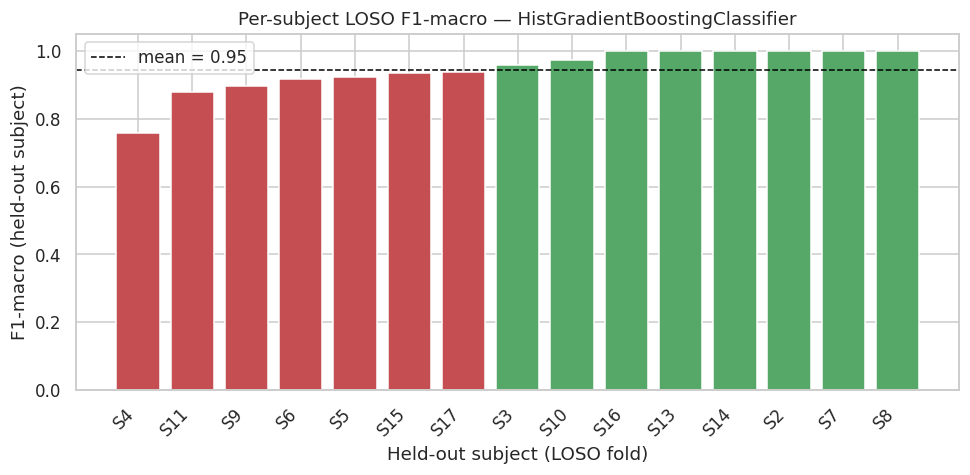

In [ ]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

os.makedirs("../figures", exist_ok=True)

# --- Per-subject F1 bar chart ---
d = fold_df.sort_values("f1_macro")
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#C44E52" if v < d["f1_macro"].median() else "#55A868" for v in d["f1_macro"]]
ax.bar(d["subject_id"], d["f1_macro"], color=colors)
ax.axhline(mean_f1, color="black", linestyle="--", linewidth=1, label=f"mean = {mean_f1:.2f}")
ax.set_ylabel("F1-macro (held-out subject)")
ax.set_xlabel("Held-out subject (LOSO fold)")
ax.set_ylim(0, 1.05)
ax.set_title("Per-subject LOSO F1-macro — HistGradientBoostingClassifier")
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
fig.savefig("../figures/loso_per_subject_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ../figures/loso_per_subject_f1.png")


Saved ../figures/loso_confusion_matrix.png


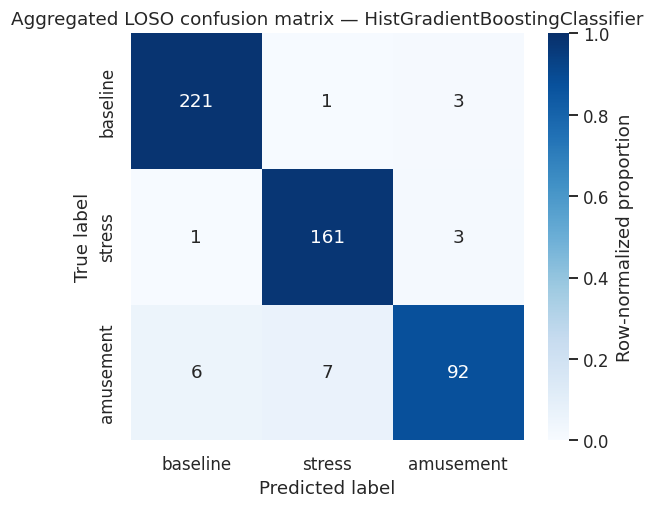

In [ ]:
# --- Aggregated confusion matrix (summed across all folds) ---
cm_agg = confusion_matrix(all_true, all_pred, labels=LABEL_NAMES)
cm_norm = cm_agg.astype(float) / cm_agg.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.5, 4.8))
sns.heatmap(cm_norm, annot=cm_agg, fmt="d", cmap="Blues", xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cbar_kws={"label": "Row-normalized proportion"},
            ax=ax, vmin=0, vmax=1)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Aggregated LOSO confusion matrix — HistGradientBoostingClassifier")
plt.tight_layout()
fig.savefig("../figures/loso_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ../figures/loso_confusion_matrix.png")


## 5. Final Model

Retrain on **all** subjects (maximizing training data for the deployed model) and persist the fitted scaler alongside the classifier — the scaler must travel with the model, since any new data needs the exact same transform applied at inference time.

In [ ]:
import joblib

scaler_final = StandardScaler()
X_scaled_final = scaler_final.fit_transform(X)

final_clf = HistGradientBoostingClassifier(max_iter=200, max_depth=6, learning_rate=0.08,
                                            class_weight="balanced", random_state=RANDOM_STATE)
final_clf.fit(X_scaled_final, y)

os.makedirs("../models", exist_ok=True)
joblib.dump(
    {"model": final_clf, "scaler": scaler_final, "feature_columns": feature_cols,
     "label_names": LABEL_NAMES, "random_state": RANDOM_STATE},
    "../models/hgb_final.joblib",
)
print("Saved ../models/hgb_final.joblib")
print(f"Final model trained on all {len(df)} windows from {df['subject_id'].nunique()} subjects.")


Saved ../models/hgb_final.joblib
Final model trained on all 495 windows from 15 subjects.


## 6. SHAP Feature Importance (optional, brief)

Computed on a sample of 100 rows, as requested.

In [ ]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
print("shap package available:", HAS_SHAP)


shap package available: False


In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_scaled_final), size=min(100, len(X_scaled_final)), replace=False)
X_sample = X_scaled_final[sample_idx]

if HAS_SHAP:
    background = shap.sample(X_scaled_final, 40, random_state=RANDOM_STATE)
    explainer = shap.Explainer(final_clf.predict_proba, background)
    shap_values = explainer(X_sample)
    mean_abs_shap = np.abs(shap_values.values).mean(axis=(0, 2))
else:
    # Falling back to this project's own from-scratch Shapley-value sampling
    # estimator (src/interpretability.py::shapley_values_sampling) -- the same
    # permutation/sampling algorithm (Strumbelj & Kononenko, 2010) SHAP itself is
    # built on, unit-tested against the Shapley efficiency property in
    # tests/test_interpretability.py.
    from interpretability import shapley_values_sampling
    print("Using the custom Shapley-value sampling estimator (see note above).")

    background_idx = rng.choice(len(X_scaled_final), size=40, replace=False)
    background = X_scaled_final[background_idx]
    pred_labels_sample = final_clf.predict(X_sample)
    class_order = list(final_clf.classes_)

    shap_matrix = np.zeros((len(X_sample), len(feature_cols)))
    for cls in LABEL_NAMES:
        mask = pred_labels_sample == cls
        if mask.sum() == 0:
            continue
        ci = class_order.index(cls)
        predict_fn = lambda Z, ci=ci: final_clf.predict_proba(Z)[:, ci]
        shap_matrix[mask] = shapley_values_sampling(predict_fn, X_sample[mask], background,
                                                     n_samples=50, rng=rng)
    mean_abs_shap = np.abs(shap_matrix).mean(axis=0)

shap_importance = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)
top15 = shap_importance.head(15)
print("\nTop 15 features by mean |Shapley value|:")
top15


Using the custom Shapley-value sampling estimator (see note above).

Top 15 features by mean |Shapley value|:


resp_std                     0.366035
acc_chest_activity_counts    0.079245
acc_wrist_activity_counts    0.062499
resp_rate_bpm                0.061539
resp_amplitude               0.023931
acc_wrist_mag_std            0.019470
emg_rms                      0.017400
resp_rate_var                0.016408
emg_burst_count              0.011507
eda_wrist_phasic_auc         0.004879
hrv_ecg_lf_hf                0.004296
eda_wrist_phasic_std         0.003981
eda_chest_phasic_auc         0.003569
temp_chest_mean              0.002392
hrv_ecg_pnn50                0.002182
dtype: float64

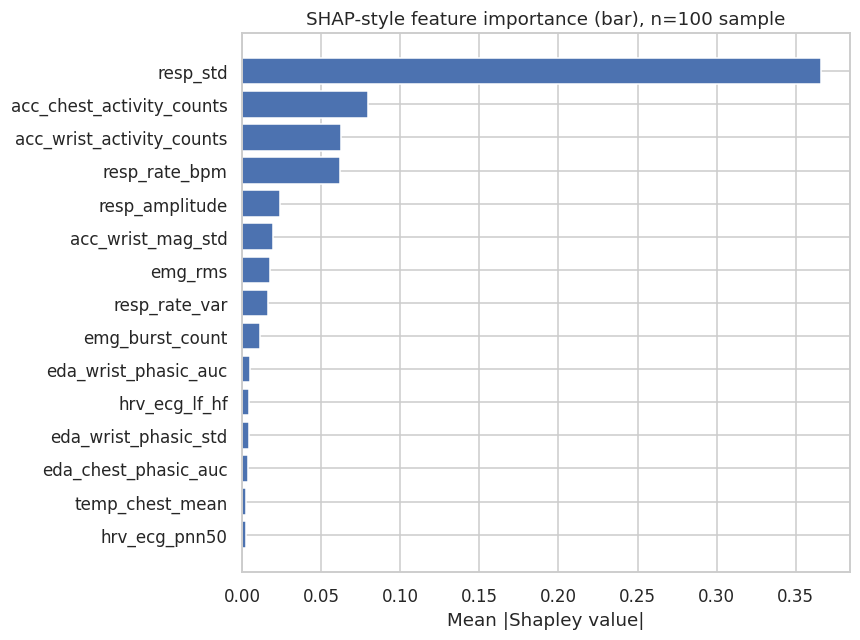

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15.index[::-1], top15.values[::-1], color="#4C72B0")
ax.set_xlabel("Mean |Shapley value|")
ax.set_title("SHAP-style feature importance (bar), n=100 sample")
plt.tight_layout()
plt.show()
